### Import and reading data

In [73]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
import os
import ctypes

# Force the dynamic linker to find libR.so before rpy2 tries to load
try:
    ctypes.CDLL('/usr/lib/R/lib/libR.so', mode=ctypes.RTLD_GLOBAL)
except Exception as e:
    print(f"Manual link failed: {e}")

os.environ['R_HOME'] = '/usr/lib/R'
os.environ['LD_LIBRARY_PATH'] = '/usr/lib/R/lib'

Manual link failed: Could not find module 'c:\usr\lib\R\lib\libR.so' (or one of its dependencies). Try using the full path with constructor syntax.


In [75]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities
import numpy as np
import pandas as pd



In [76]:
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
os.chdir('/Users/Apc/graphical-sampling/simulations')

In [ ]:
# Loading the data and preparing the DataFrames for sampling

import os
import pandas as pd
import numpy as np

# Assuming inclusion_probabilities is defined elsewhere or imported
# from your package
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv", "aggregated_1000.csv", "regular_1000.csv"]

def popus(n, path="populations/real"):
    dfs = {} # Better to define inside to keep it clean
    for f in files:
        full_path = os.path.join(path, f)
        if not os.path.exists(full_path):
            print(f"Warning: {full_path} not found.")
            continue
            
        df = pd.read_csv(full_path)
        N_pop = len(df)
        name = f.replace('.csv', '')
        
        # Equal Probabilities (Standard for all)
        pik_ep = np.repeat(n / N_pop, N_pop)
        
        if f in ["aggregated.csv", "regular.csv",  "aggregated_1000.csv", "regular_1000.csv"]:
            coords = df.to_numpy()
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'z'      : np.ones(N_pop) # Placeholder if z is missing
            })

        elif f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            # Unequal Probabilities (UP)
            pik_up = inclusion_probabilities(df['copper'].to_numpy().copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['cadmium']
            })

        elif f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5, 100)
            pik_up = inclusion_probabilities(AREA.copy(), n)
            dfs[f'df_{name}'] = pd.DataFrame({
                'coord_x': coords[:, 0],
                'coord_y': coords[:, 1],
                'pik_ep' : pik_ep,
                'pik_up' : pik_up,
                'z'      : df['AREA_A']
            })
            
    return dfs

In [78]:
# changing the angle of the population for testing the robustness of the sampling algorithms

import numpy as np
import pandas as pd

def rotate_population(df, alpha_degrees):
    # Convert angle to radians
    alpha_rad = np.radians(alpha_degrees)
    
    # Rotation Matrix components
    cos_a = np.cos(alpha_rad)
    sin_a = np.sin(alpha_rad)
    
    # Extract coordinates
    x = df['coord_x'].values
    y = df['coord_y'].values
    
    # Apply Rotation:
    # x' = x*cos(a) - y*sin(a)
    # y' = x*sin(a) + y*cos(a)
    df['coord_x'] = x * cos_a - y * sin_a
    df['coord_y'] = x * sin_a + y * cos_a
    
    return df

# Example use: Rotate 45 degrees
# df_rotated = rotate_population(df.copy(), 45)

In [79]:
# Diagnostic function to check inclusion probabilities and plot deviations

import numpy as np
import matplotlib.pyplot as plt

def check_inclusions(design, plot=True, title="FIP Deviation"):
    """
    Performs a statistical diagnostic on the design to ensure 
    Inclusion Probabilities (FIP) are perfectly preserved.
    """
    # 1. Extract Data
    empirical_fip = design.fip 
    target_fip = design.pop.inclusions
    diff = empirical_fip - target_fip
    max_dev = np.abs(diff).max()

    # 2. Print Summary
    print(f"--- Inclusion Probability Diagnostic ---")
    print(f"Total Design Mass: {empirical_fip.sum():.6f} (Target: {design.pop.n})")
    print(f"Max Absolute Deviation: {max_dev:.2e}")
    print(f"Mean Absolute Deviation: {np.abs(diff).mean():.2e}")

    # 3. Validation Logic
    if np.allclose(empirical_fip, target_fip, atol=1e-6):
        print("✅ SUCCESS: Inclusion probabilities are perfectly preserved!")
    else:
        fixed_count = len(design.order.fixed_ids)
        print(f"❌ WARNING: Significant deviation! Frozen units: {fixed_count}")

    # 4. Optional Plotting
    if plot:
        plt.figure(figsize=(10, 2))
        plt.plot(diff, color='red', lw=1, alpha=0.7)
        plt.title(f"{title} (Max Dev: {max_dev:.2e})")
        plt.axhline(0, color='black', lw=0.5, ls='--')
        plt.ylabel("Delta")
        plt.xlabel("Unit Index")
        plt.grid(True, alpha=0.2)
        plt.show()

In [80]:
# Debugging function to visualize the swap in the specific zone

from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np
def audit_intelligent_swap(order_obj, coords, idx_i, idx_j, c_idx, z_idx):
    """
    Visualizes the specific zone where a swap is happening.
    """
    plt.figure(figsize=(6, 6))
    
    # 1. Get the specific zone data
    active_zone = order_obj.clusters[c_idx].zones[z_idx]
    zone_indices = active_zone.indices # Use the property to get sorted indices
    
    # 2. Plot all points in the background (faint)
    plt.scatter(coords[:, 0], coords[:, 1], c='gray', s=5, alpha=0.1, label='Population')
    
    # 3. Highlight all points in this SPECIFIC zone
    zone_coords = coords[zone_indices]
    plt.scatter(zone_coords[:, 0], zone_coords[:, 1], c='green', s=20, alpha=0.4, label=f'Zone {z_idx}')
    
    # 4. Draw the Convex Hull of the Zone (The "Green Box")
    if len(zone_coords) >= 3:
        hull = ConvexHull(zone_coords)
        for simplex in hull.simplices:
            plt.plot(zone_coords[simplex, 0], zone_coords[simplex, 1], 'g-', lw=2)
            
    # 5. Highlight the two units being swapped
    # Red = Unit i, Blue = Unit j
    plt.scatter(coords[idx_i, 0], coords[idx_i, 1], c='red', s=100, edgecolors='black', label='Unit I', zorder=5)
    plt.scatter(coords[idx_j, 0], coords[idx_j, 1], c='blue', s=100, edgecolors='black', label='Unit J', zorder=5)
    
    plt.title(f"Cluster {c_idx} | Zone {z_idx} | Swapping ID {idx_i} with {idx_j}")
    plt.legend()
    plt.show()

In [81]:
# Function to save the full GBFS engine state, including the search frontier and best design
import os
import pickle
from datetime import datetime

def save_gbfs_state(engine, folder="best_designs"):
    """
    Saves the full GBFS engine state, including the search frontier and best design.
    """
    os.makedirs(folder, exist_ok=True)
    
    # Extract metadata for a clean filename
    pop_label = getattr(engine.best_design.pop, 'label', 'pop').replace(" ", "_")
    score = engine.best_criteria_value
    timestamp = datetime.now().strftime("%m%d_%H%M")
    
    # Detect current zone configuration from the best design
    # This helps identify if the file is a 40Z or 1Z version
    num_clusters = len(engine.best_design.order.clusters)
    num_zones = len(engine.best_design.order.clusters[0].zones) if num_clusters > 0 else 0
    
    filename = f"GRIZZLY_{pop_label}_C{num_clusters}Z{num_zones}_score{score:.4f}_pop_{popu}_{timestamp}.pkl"
    save_path = os.path.join(folder, filename)
    
    with open(save_path, 'wb') as f:
        pickle.dump(engine, f)
    
    print(f"✅ Full search state saved: {save_path}")
    print(f"Candidates waiting in Open Set: {len(engine.open_set)}")
    return save_path

In [82]:
# Function to load a saved GBFS engine state from the best_designs folder

def load_gbfs_state(filename):
    """
    Loads a saved GBFS engine state from the best_designs folder.
    """
    # Ensure we look in the right folder if only a filename is provided
    if not os.path.exists(filename):
        filename = os.path.join("best_designs", filename)
        
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            loaded_engine = pickle.load(f)
        
        print(f"🚀 Grizzly Resumed!")
        print(f"Best Score Found: {loaded_engine.best_criteria_value:.6f}")
        print(f"Hierarchy State:  {len(loaded_engine.best_design.order.clusters)} Clusters")
        print(f"Frontier Size:    {len(loaded_engine.open_set)} candidates")
        return loaded_engine
    else:
        print(f"❌ File not found: {filename}")
        return None

In [83]:
def release_full_grizzly(old_engine):
    """
    Takes a restricted engine (40 zones), flattens every single candidate 
    in its open_set, and returns a brand new 'Released' engine.
    """
    print(f"--- Global Release Initiated ---")
    print(f"Processing {len(old_engine.open_set)} candidates from the frontier...")
    
    # 1. First, flatten the absolute best design to use as the "seed"
    flat_best = old_engine.best_design.flatten()
    
    # 2. Create the fresh engine using that flat_best as the initial design
    # This prevents the ValueError: min() arg is empty
    new_engine = gs.search.GreedyBestFirstSearch(initial_designs=[flat_best], criteria=old_engine.criteria)
    
    # 3. Flatten the rest of the Open Set and add them
    flattened_count = 0
    import heapq
    for val, _, move_type, design in old_engine.open_set:
        try:
            # Flatten the candidate
            flat_candidate = design.flatten()
            
            # Avoid duplicating the best_design we already added
            if flat_candidate == flat_best:
                continue
                
            # Push into the new engine's open_set
            heapq.heappush(new_engine.open_set, (val, next(new_engine._counter), 'order_change', flat_candidate))
            flattened_count += 1
        except Exception:
            continue
            
    # 4. Ensure the engine starts with a clean closed_set
    new_engine.closed_set = set()
    
    print(f"✅ Success! New engine populated with {flattened_count + 1} global candidates.")
    print(f"Current Best Score: {new_engine.best_criteria_value:.6f}")
    
    return new_engine

In [84]:
import numpy as np
import graphical_sampling as gs

def restructure_design(pop, num_clusters=4, zones_per_cluster=16, point_strat='knight_move'):
    """
    Rebuilds the spatial hierarchy with a Self-Healing retry loop to prevent empty clusters.
    """
    print(f"--- Restructuring Design ---")
    
    n_total = num_clusters * zones_per_cluster
    grid_x = int(np.sqrt(num_clusters))
    zone_grid_x = int(np.sqrt(zones_per_cluster))
    
    # Self-Healing Retry Loop (Max 3 attempts)
    max_attempts = 3
    for attempt in range(max_attempts):
        
        # Setup parameters: Use 'expanded' first, but drop it if it causes empty clusters
        clustering_params = {
            'n': n_total,
            'centroid_grid_x': grid_x,
            'r_sample_per_cluster': zones_per_cluster,
            'split_size': 1
        }
        if attempt == 0:
            clustering_params['init_clust_method'] = 'expanded'
            
        fbn = gs.clustering.FIPBalancedNMeans(**clustering_params)
        
        init_log = "'expanded'" if attempt == 0 else "Default"
        print(f"\nFitting {num_clusters} Clusters (Attempt {attempt+1} | init={init_log})...")
        fbn.fit(pop)
        
        try:
            print(f"Fitting {zones_per_cluster} Zones per Cluster...")
            fbn.fit_zones(num_zones=zones_per_cluster, mode='cluster', centroid_grid_x_zone=zone_grid_x)
            
            # CRITICAL CHECK: Did any parent cluster end up empty?
            empty_zones = sum(1 for c in fbn.clusters if len(c.zones) == 0)
            if empty_zones > 0:
                raise ValueError("zero-size array") # Force a retry
                
            # If we pass the check, the grid is mathematically flawless!
            break 
            
        except ValueError as e:
            if "zero-size array" in str(e):
                print(f"⚠️ Spatial Conflict: An empty cluster was detected.")
                if attempt == max_attempts - 1:
                    print("🔄 Max retries reached. Forcing 'sweep_yx' fallback...")
                    fbn.fit_zones(num_zones=zones_per_cluster, mode='sweep_yx')
            else:
                raise e

    # Final Safety Net before building the Order
    for i, cluster in enumerate(fbn.clusters):
        if len(cluster.zones) == 0:
            raise RuntimeError(f"CRITICAL FAULT: Cluster {i} has 0 points. The geometry cannot support {num_clusters} clusters. Reduce K_NEW.")

    print(f"Building Order and Design...")
    new_order = gs.Order.from_clusters(pop, fbn.clusters, point_strategy=point_strat)
    new_design = gs.Design.from_order(pop, new_order)
    
    print(f"✅ Success! Architecture: {num_clusters}C x {zones_per_cluster}Z")
    return new_design

In [85]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n

# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     initial_design.nht_variance,
#     # srs_var / initial_design.nht_variance,
#     0,
#     0,
#     initial_design.density_disparity[0],
#     initial_design.density_disparity[1],
#     initial_design.voronoi[0],
#     initial_design.voronoi[1],
#     initial_design.moran[0],
#     initial_design.moran[1],
#     initial_design.local_balance[0],
#     initial_design.local_balance[1],
# ]

# print(", ".join(map(str, plain_flat)))


### Parameters

In [86]:
# --- Parameters ---
popu = 'df_regular_1000'
ep_or_up = 'pik_ep'
n = 20
df = popus(n)[popu]
df = rotate_population(df.copy(),0)
N = len(df)

r_sample_per_cluster = 1
centroid_grid_x = 4
centroid_grid_x_zone = 9
num_zones_cluster = [100]
num_zones_sweep = [(2, 2)]
num_splits = [1]
topological = True
shift_jumps = [0]
shuffle=False

# --- Data Preparation ---
target_df = df
coords_data = target_df[['coord_x', 'coord_y']].to_numpy()
inclusions_data = target_df[ep_or_up].to_numpy()
# np.random.seed(123)
# inclusions_data = inclusion_probabilities(np.random.random(N), n)
# print(inclusions_data)
variable_data = target_df['z'].to_numpy() if 'z' in target_df.columns else inclusions_data

# --- Population & Clustering ---
pop = gs.Population(coords_data, inclusions_data, n=n, variable=variable_data)

fbn = gs.clustering.FIPBalancedNMeans(
    n=n, 
    centroid_grid_x=centroid_grid_x, 
    r_sample_per_cluster=r_sample_per_cluster, 
    init_clust_method='expanded', 
    split_size=1
)

fbn.fit(pop)
fbn.fit_zones(num_zones=num_zones_sweep[0], mode='sweep_yx')
# fbn.fit_zones(num_zones=num_zones_cluster[0], mode='cluster')

# --- Visualization ---
fbn.plot(mode='soft')

KeyError: 'df_regular_1000'

### Pre-Process

In [ ]:
# --- Parameters ---
# Re-ordered to put None and lexico_yx first (establish a strong baseline early)
all_strategies = ['None' ,'lexico_yx', 'projection', 'spiral', 'angle', 
                    'dist_from_origin', 'dist_from_centroids', 'max_coord', 'lexico_xy', 'snake', 'knight_move', 'hilbert', 'snake_refined',
                    'hilbert_strong', 'morton_grts', 'snake_staggered']
point_strategies = all_strategies
        
# point_strategies = ['knight_move', 'snake', 'lexico_xy', 'lexico_yx']
point_strategies = ['dist_from_centroids ']

zone_strategies = all_strategies
                  
# zone_strategies = ['knight_move', 'snake', 'lexico_xy', 'lexico_yx']
zone_strategies = ['None']
zone_modes = ['sweep_xy', 'sweep_yx']
#zone_modes = ['cluster']
# Ensure shift_jumps is defined in your notebook before this

initial_designs = []
track = []
min_moran = float('inf') 

# Correct calculation for total iterations
num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits) * len(shift_jumps)

# Initialize Progress Bar
pbar = tqdm(product(point_strategies, zone_strategies, zone_modes, num_splits, shift_jumps), total=num_designs)

for point_strategy, zone_strategy, zone_mode, num_split, shift_jump in pbar:
    
    # Selection of zone counts
    list_of_num_zones = num_zones_cluster if zone_mode == 'cluster' else num_zones_sweep

    for num_zones in list_of_num_zones:
        # 1. Fresh Clustering
        fbn = gs.clustering.FIPBalancedNMeans(
            n=n,
            centroid_grid_x=centroid_grid_x, 
            r_sample_per_cluster=r_sample_per_cluster, 
            init_clust_method='expanded', 
            split_size=1
        )
        fbn.fit(pop)
        fbn.fit_zones(num_zones=num_zones, mode=zone_mode)
        
        # 2. Build Order
        try:
            # IMPORTANT: Set shuffle=True here to use your new Prime Phase Shift logic
            order = gs.Order.from_clusters(
                pop, 
                fbn.clusters, 
                zone_strategy=zone_strategy, 
                point_strategy=point_strategy, 
                num_splits=num_split,
                topological=topological,
                shift_jump=shift_jump,
                shuffle=shuffle,
                # THE FIX: Only pass as tuple, otherwise let it auto-calculate
                grid_dims=num_zones if isinstance(num_zones, tuple) else None,
            )

            # 3. Create Design
            design = gs.Design.from_order(pop, order)

            # 4. Evaluate Moran Index
            moran_val = design.moran[0]
            
            # --- BASELINE FIX: Print the very first valid result ---
            if len(track) == 0:
                min_moran = moran_val
                print(f"[INITIAL BASELINE] Moran: {moran_val:.6f} | ZS: {zone_strategy} | PS: {point_strategy}")

            # --- IMPROVEMENT LOGIC ---
            if moran_val < min_moran:
                min_moran = moran_val
                # Using aligned printing for clarity
                print(f"[NEW BEST] Moran: {moran_val:.6f} | ZS: {str(zone_strategy):<15} | PS: {str(point_strategy):<15} | Jump: {shift_jump}")
            
            # Show live status next to the bar
            pbar.set_postfix({"Best": f"{min_moran:.6f}"})

            initial_designs.append(design)
            track.append((moran_val, design, zone_strategy, point_strategy, zone_mode, num_zones, shift_jump))
            
        except Exception as e:
            # If everything shows nothing, comment out 'continue' and uncomment 'raise e' to see why
            continue

# --- Final Ranking Output ---
if not track:
    print("\n[ERROR] No designs were successfully generated. Check your try/except block.")
else:
    results = sorted(track, key=lambda x: x[0])
    best = results[0]

    print(f"\n{'='*40}")
    print(f"      OPTIMIZATION COMPLETE")
    print(f"{'='*40}")
    print(f"Best Moran:      {best[0]:.6f}")
    print(f"Zone Strategy:   {best[2]}")
    print(f"Point Strategy:  {best[3]}")
    print(f"Zone Mode:       {best[4]}")
    print(f"Num Zones:       {best[5]}")
    print(f"Shift Jump:      {best[6]}")
    print(f"{'='*40}")

 25%|██▌       | 1/4 [00:01<00:04,  1.44s/it, Best=-0.238959]

[INITIAL BASELINE] Moran: -0.238959 | ZS: None | PS: dist_from_centroids 


 75%|███████▌  | 3/4 [00:05<00:01,  1.78s/it, Best=-0.244393]

[NEW BEST] Moran: -0.244393 | ZS: None            | PS: dist_from_centroids  | Jump: 0


100%|██████████| 4/4 [00:06<00:00,  1.56s/it, Best=-0.244393]


      OPTIMIZATION COMPLETE
Best Moran:      -0.244393
Zone Strategy:   None
Point Strategy:  dist_from_centroids 
Zone Mode:       sweep_yx
Num Zones:       (2, 2)
Shift Jump:      0


In [ ]:
z = sorted(track, key=lambda x: x[0], reverse=False)
# Add 'jump' to the end of the unpacking list
initial_moran, initial_design, zs, ps, zm, nz, jump = z[0]
len(initial_design.all_samples_and_probs[0])
initial_design.all_samples_and_probs[1].sum()

np.float32(1.0)

In [ ]:
check_inclusions(initial_design, plot=False)

--- Inclusion Probability Diagnostic ---
Total Design Mass: 20.000001 (Target: 20)
Max Absolute Deviation: 4.90e-10
Mean Absolute Deviation: 4.90e-10
✅ SUCCESS: Inclusion probabilities are perfectly preserved!


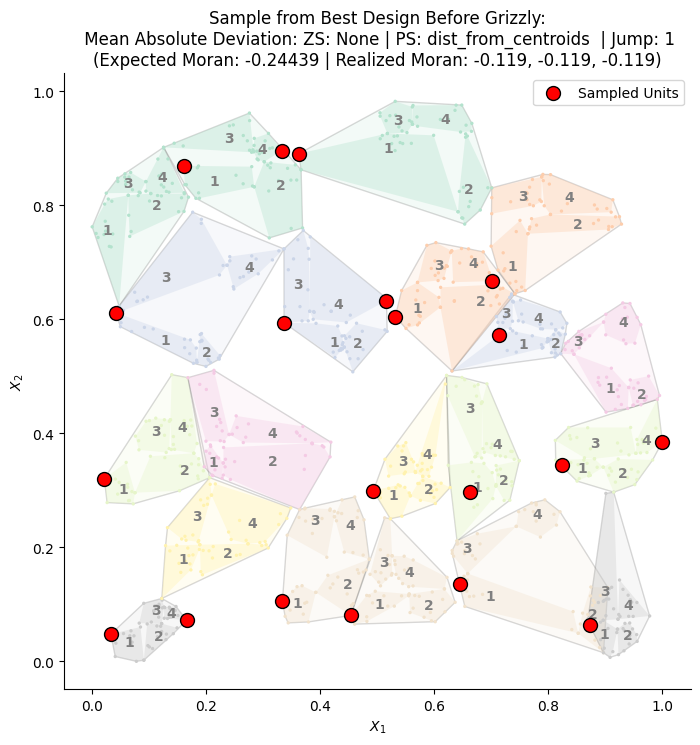

Sampled Unit Indices: [194 963 517 778 842 203 717 271 402 916 661 152 601 154 668 227 996 491
  58  62]


In [ ]:
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Use the best design
best_design = initial_design 

# 3. Draw the background (Clustering and Zones)
fbn.plot(mode='soft', ax=ax)

# 4. Extract a SINGLE sample (2D array: 1 row, n columns)
sample_indices_2d = best_design.sample(1)
sample_indices = sample_indices_2d[0] 

# 5. Calculate Moran for this SPECIFIC realization
# We use the Moran indexer on the current coordinates
realized_moran_tille = Moran(best_design.pop, method='tille').score(sample_indices_2d)[0]
realized_moran_raphael = Moran(best_design.pop, method='raphael').score(sample_indices_2d)[0]
realized_moran_robertson = Moran(best_design.pop, method='robertson').score(sample_indices_2d)[0]

# 6. Scatter the sampled points in Red
all_coords = best_design.pop.coords
ax.scatter(
    all_coords[sample_indices, 0], 
    all_coords[sample_indices, 1], 
    color='red', 
    s=100, 
    edgecolors='black', 
    label='Sampled Units',
    zorder=15 
)

# 7. Update title with both Expected and Realized Moran
ax.set_title(f"Sample from Best Design Before Grizzly:\n Mean Absolute Deviation: ZS: {best[2]} | PS: {best[3]} | Jump: {shift_jump}\n(Expected Moran: {best_design.moran[0]:.5f} | Realized Moran: {realized_moran_tille:.3f}, {realized_moran_raphael:.3f}, {realized_moran_robertson:.3f})")
ax.legend()
plt.show()

print(f"Sampled Unit Indices: {sample_indices}")

In [ ]:
initial_design = results[0][1]
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch([initial_design], criteria)

In [ ]:
print(N)

1027


In [ ]:
# test_order = initial_design.order.copy()
# test_order.change(
#     num_clusters=1, 
#     num_zones=1, 
#     num_changes=1, 
#     num_zone_changes=0, 
#     window=None, 
#     coords=pop.coords, 
#     debugger_func=audit_intelligent_swap
# )
gbfs.run(
    max_iterations=5000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=100,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(1,1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1,1),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='random',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.33,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    window= None, #lambda iter: random.randint(1, 5)
    
    n_jobs = -1,
    
    backtrack_depth=1, 
    
    stagnation_limit=5000)
gbfs.initial_designs =  [gbfs.best_design]
check_inclusions(gbfs.best_design, plot=False)
# After your 100 iterations are done
# current_file = save_gbfs_state(gbfs)

Starting fresh: Initializing Open Set.
--- Parallel GBFS: Batch Size=1, Workers=-1 ---
WOWITR    0 | IMP   1-  0 | RSV -0.244393 | BST -0.244393 [ORD] | NEW -0.244419 [ORD] | 20C x  4Z | SIZ 1030 | ENT 6.9362
WOWITR    0 | IMP   2-  0 | RSV -0.244393 | BST -0.244419 [ORD] | NEW -0.244617 [ORD] | 20C x  4Z | SIZ 1030 | ENT 6.9362
WOWITR    0 | IMP   3-  0 | RSV -0.244393 | BST -0.244617 [ORD] | NEW -0.244650 [ORD] | 20C x  4Z | SIZ 1030 | ENT 6.9362
WOWITR    0 | IMP   4-  0 | RSV -0.244393 | BST -0.244650 [ORD] | NEW -0.245098 [ORD] | 20C x  4Z | SIZ 1030 | ENT 6.9362
WOWITR    1 | IMP   5-  0 | RSV -0.244393 | BST -0.245098 [ORD] | NEW -0.245125 [ORD] | 20C x  4Z | SIZ 1030 | ENT 6.9362
WOWITR    1 | IMP   6-  0 | RSV -0.244393 | BST -0.245125 [ORD] | NEW -0.245204 [ORD] | 20C x  4Z | SIZ 1030 | ENT 6.9362
WOWITR    1 | IMP   7-  0 | RSV -0.244393 | BST -0.245204 [ORD] | NEW -0.245297 [ORD] | 20C x  4Z | SIZ 1030 | ENT 6.9362
WOWITR    1 | IMP   8-  0 | RSV -0.244393 | BST -0.245297 [

KeyboardInterrupt: 

In [ ]:
raise KeyboardInterrupt("Execution stopped by user.")

KeyboardInterrupt: Execution stopped by user.

### GRIZZLY

In [ ]:
gbfs = load_gbfs_state('GRIZZLY_pop_C20Z1_score-0.3861_0428_0934.pkl')
# gbfs = load_gbfs_state('GRIZZLY_pop_C1Z40_score-0.3571_0426_1956.pkl')

🚀 Grizzly Resumed!
Best Score Found: -0.386140
Hierarchy State:  20 Clusters
Frontier Size:    1888 candidates


In [ ]:
# test_order = initial_design.order.copy()
# test_order.change(
#     num_clusters=1, 
#     num_zones=1, 
#     num_changes=1, 
#     num_zone_changes=0, 
#     window=None, 
#     coords=pop.coords, 
#     debugger_func=audit_intelligent_swap
# )
gbfs.run(
    max_iterations=5000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=100,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(1,1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1,1),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='random',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.33,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    window= None, #lambda iter: random.randint(1, 5)
    
    n_jobs = -1,
    
    backtrack_depth=1, 
    
    stagnation_limit=5000)
gbfs.initial_designs =  [gbfs.best_design]
check_inclusions(gbfs.best_design, plot=False)
# After your 100 iterations are done
# current_file = save_gbfs_state(gbfs)

Resuming search with 796 candidates in memory.
--- Parallel GBFS: Batch Size=1, Workers=-1 ---
🏆 WOWW! RESERVOIR UPDATED! Absolute Best: -0.266329 🏆


NameError: name 'act_c' is not defined

In [ ]:
current_file = save_gbfs_state(gbfs)

✅ Full search state saved: best_designs\GRIZZLY_pop_C20Z1_score-0.2407_pop_df_aggregated_0429_0341.pkl
Candidates waiting in Open Set: 0


C:\Users\Apc\AppData\Local\Temp\ipykernel_1356\1502334494.py:26: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  pickle.dump(engine, f)


In [ ]:
current_file = save_gbfs_state(gbfs_global)

C:\Users\Apc\AppData\Local\Temp\ipykernel_13080\1502334494.py:26: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  pickle.dump(engine, f)


✅ Full search state saved: best_designs\GRIZZLY_pop_C1Z1_score-0.2881_pop_df_aggregated_0429_2307.pkl
Candidates waiting in Open Set: 897


In [ ]:
best_design = gbfs.best_design

### Global Searching!

Restricted Borders: 0
Released Borders:   0


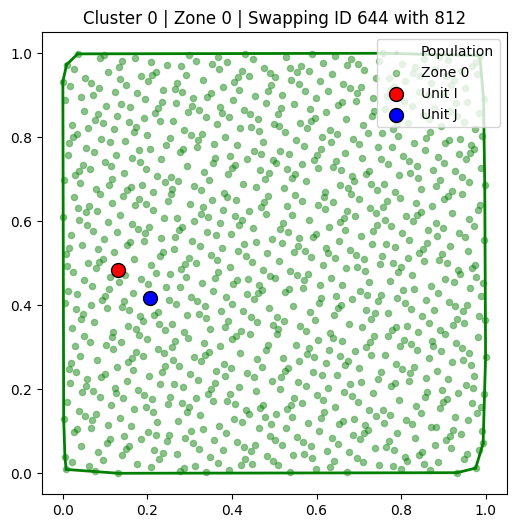

In [ ]:
# Use the class method (Option 2) - it is the cleanest approach
polished_start = gbfs.best_design.flatten()

gbfs.open_set = [] 
gbfs.closed_set = set()
gbfs.top_k = []

# Diagnostic prints to verify the "Release"
print(f"Restricted Borders: {len(gbfs.best_design.order.fixed_ids)}")
print(f"Released Borders:   {len(polished_start.order.fixed_ids)}")

# Update the search engine state with the released design
gbfs.initial_designs = [polished_start]
gbfs.best_design = polished_start
gbfs.best_criteria_value = gbfs.criteria(polished_start)

test_order = gbfs.best_design.order.copy()

# This will pop up the plot for the very first swap it attempts
test_order.change(
    num_clusters=1, 
    num_zones=1, 
    num_changes=1, 
    num_zone_changes=0, 
    window=2, 
    coords=pop.coords, 
    debugger_func=audit_intelligent_swap
)
# Now run gbfstabu.run(...) with global parameters (num_partitions=1)

In [ ]:
# 1. Flatten the entire frontier
gbfs_global = release_full_grizzly(gbfs)

# 2. Grab the order from the NEW, flattened design
test_order = gbfs_global.best_design.order.copy()

--- Global Release Initiated ---
Processing 196 candidates from the frontier...
✅ Success! New engine populated with 197 global candidates.
Current Best Score: -0.245827


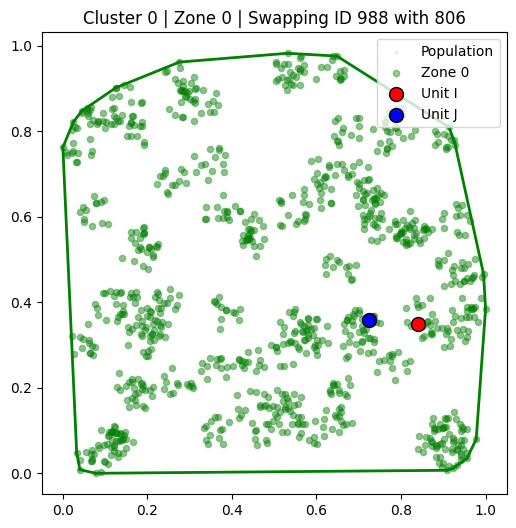

In [ ]:
test_order.change(
    num_clusters=1, 
    num_zones=1, 
    num_changes=1, 
    num_zone_changes=0, 
    window=None, 
    coords=pop.coords, 
    debugger_func=audit_intelligent_swap
)

In [ ]:
gbfs_global.run(
    max_iterations=5000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=500,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=200,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)
                                
    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1, 1),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='defult',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.005,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1,               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
    window=None,
    
    n_jobs = -1,
    backtrack_depth=1, 
    stagnation_limit=5000
)
check_inclusions(gbfs.best_design, plot=False)

Resuming search with 698 candidates in memory.
--- Parallel GBFS: Batch Size=1, Workers=-1 ---
WOWITR    0 | IMP   1-  0 | RSV -0.272346 | BST -0.272346 [ORD] | NEW -0.272400 [ORD] |  1C x  1Z | SIZ 1027 | ENT 6.9344
WOWITR    0 | IMP   2-  0 | RSV -0.272346 | BST -0.272400 [ORD] | NEW -0.272413 [ORD] |  1C x  1Z | SIZ 1027 | ENT 6.9344
WOWITR    2 | IMP   3-  0 | RSV -0.272346 | BST -0.272413 [ORD] | NEW -0.272487 [ORD] |  1C x  1Z | SIZ 1027 | ENT 6.9344
WOWITR    2 | IMP   4-  0 | RSV -0.272346 | BST -0.272487 [ORD] | NEW -0.272732 [ORD] |  1C x  1Z | SIZ 1027 | ENT 6.9344
WOWITR    3 | IMP   5-  0 | RSV -0.272346 | BST -0.272732 [ORD] | NEW -0.272780 [ORD] |  1C x  1Z | SIZ 1027 | ENT 6.9344
WOWITR    4 | IMP   6-  0 | RSV -0.272346 | BST -0.272780 [ORD] | NEW -0.273022 [ORD] |  1C x  1Z | SIZ 1027 | ENT 6.9344
WOWITR    4 | IMP   7-  0 | RSV -0.272346 | BST -0.273022 [ORD] | NEW -0.273109 [ORD] |  1C x  1Z | SIZ 1027 | ENT 6.9344
WOWITR    5 | IMP   8-  0 | RSV -0.272346 | BST -0.

KeyboardInterrupt: 

In [ ]:
import numpy as np
import graphical_sampling as gs

def investigate_swap_effect(base_design, window=None, num_swaps=1):
    """
    Applies swaps to the order and calculates the impact on the Moran index.
    """
    # 1. Create a deep copy of the order to avoid modifying your original design
    test_order = base_design.order.copy()
    
    # 2. Perform the swap between units
    test_order.change(
        num_clusters=1, 
        num_zones=1, 
        num_changes=num_swaps, # 1 change = 1 swap of two units
        num_zone_changes=0, 
        window=window          # 1 for local, None for global within zone
    )
    
    # 3. Compile the "mega order" into a new Design
    new_design = gs.Design.from_order(base_design.pop, test_order)
    
    # 4. Compare the expected Moran index
    original_moran = base_design.moran[0]
    new_moran = new_design.moran[0]
    diff = new_moran - original_moran
    
    print(f"--- Window Size: {window} ---")
    print(f"Original Moran: {original_moran:.6f}")
    print(f"New Moran:      {new_moran:.6f}")
    print(f"Difference:     {diff:+.6f} {'(Small Change)' if abs(diff) < 0.01 else '(Large Change)'}\n")

# ==============================================================
# HOW TO USE IT WITH YOUR ZONED AND FLATTENED VERSIONS
# ==============================================================

print(">>> TESTING ORIGINAL ZONED VERSION <<<")
# The swap happens within ONE specific localized zone
investigate_swap_effect(best_design, window=1)
investigate_swap_effect(best_design, window=None)

print(">>> TESTING FLATTENED (RELEASED) VERSION <<<")
# The swap happens across the entire map globally (1 Super Zone)
flat_design = best_design.flatten()
investigate_swap_effect(flat_design, window=1)
investigate_swap_effect(flat_design, window=None)

>>> TESTING ORIGINAL ZONED VERSION <<<
--- Window Size: 1 ---
Original Moran: -0.361060
New Moran:      -0.360522
Difference:     +0.000537 (Small Change)

--- Window Size: None ---
Original Moran: -0.361060
New Moran:      -0.358035
Difference:     +0.003025 (Small Change)

>>> TESTING FLATTENED (RELEASED) VERSION <<<
--- Window Size: 1 ---
Original Moran: -0.361060
New Moran:      -0.360609
Difference:     +0.000451 (Small Change)

--- Window Size: None ---
Original Moran: -0.361060
New Moran:      -0.356134
Difference:     +0.004925 (Small Change)



In [ ]:
import cv2
import numpy as np
import pandas as pd

def extract_coordinates_from_image(image_path, expected_points=1000):
    # 1. Read the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        raise ValueError(f"Could not load image at {image_path}")
        
    # 2. Threshold: Convert to strict black and white
    _, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)
    
    # 3. Find ALL contours (Changed from RETR_EXTERNAL to RETR_LIST)
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    points = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        
        # Filter: Exclude the giant border and tiny noise, keep the dots
        if 5 < area < 500: 
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX = M["m10"] / M["m00"]
                cY = M["m01"] / M["m00"]
                points.append([cX, cY])
                
    points = np.array(points)
    
    print(f"[{image_path}] Found {len(points)} dots. (Target: {expected_points})")
    
    if len(points) == 0:
        print("  -> ERROR: Still no dots found. Check the area filter.")
        return None
    
    # 4. Invert the Y-axis (Images go top-to-bottom, Cartesian goes bottom-to-top)
    points[:, 1] = img.shape[0] - points[:, 1]
    
    # 5. Scale mathematically to [0, 1] space using Min-Max scaling
    points[:, 0] = (points[:, 0] - np.min(points[:, 0])) / (np.max(points[:, 0]) - np.min(points[:, 0]))
    points[:, 1] = (points[:, 1] - np.min(points[:, 1])) / (np.max(points[:, 1]) - np.min(points[:, 1]))
    
    return points

# ==========================================
# Execution
# ==========================================

# 1. Extract Regular Population
# Update these filenames to match exactly how they are saved on your computer!
regular_coords = extract_coordinates_from_image('plot/regular_plot.png')

if regular_coords is not None:
    df_regular = pd.DataFrame(regular_coords, columns=['x', 'y'])
    df_regular.to_csv('exact_regular_population.csv', index=False)
    print("Regular Population saved successfully!")

# 2. Extract Aggregated Population
aggregated_coords = extract_coordinates_from_image('plot/aggregated_plot.png')

if aggregated_coords is not None:
    df_aggregated = pd.DataFrame(aggregated_coords, columns=['x', 'y'])
    df_aggregated.to_csv('exact_aggregated_population.csv', index=False)
    print("Aggregated Population saved successfully!")

[plot/regular_plot.png] Found 841 dots. (Target: 1000)
Regular Population saved successfully!
[plot/aggregated_plot.png] Found 225 dots. (Target: 1000)
Aggregated Population saved successfully!


In [ ]:
import cv2
import numpy as np
import pandas as pd

def extract_and_separate_dots(image_path, target_points=1000):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image at {image_path}")
        
    _, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    # 1. Filter out giant borders/text and find valid blobs
    valid_contours = []
    areas = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 2 < area < 5000: # 5000 allows massive overlapping clusters
            valid_contours.append(cnt)
            areas.append(area)
            
    if not valid_contours:
        print(f"[{image_path}] No valid contours found.")
        return None
        
    # 2. Estimate the size of a SINGLE, unmerged dot
    # The 10th percentile area represents one distinct dot
    single_dot_area = np.percentile(areas, 10) 
    if single_dot_area == 0: single_dot_area = 1
    
    # 3. Distribute points based on the size of the blobs
    raw_points = []
    for cnt in valid_contours:
        area = cv2.contourArea(cnt)
        # Calculate how many dots are merged in this blob (minimum 1)
        num_dots_in_blob = max(1, int(round(area / single_dot_area)))
        
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cX = M["m10"] / M["m00"]
            cY = M["m01"] / M["m00"]
            
            # If multiple dots are in the blob, spread them out slightly with jitter
            for _ in range(num_dots_in_blob):
                jitter_x = np.random.normal(0, 1.5) if num_dots_in_blob > 1 else 0
                jitter_y = np.random.normal(0, 1.5) if num_dots_in_blob > 1 else 0
                raw_points.append([cX + jitter_x, cY + jitter_y])
                
    raw_points = np.array(raw_points)
    current_count = len(raw_points)
    print(f"[{image_path}] Blob analysis estimated {current_count} dots.")
    
    # 4. Strict correction to EXACTLY 1000 points
    if current_count > target_points:
        # Drop excess overlapping points randomly
        indices = np.random.choice(current_count, target_points, replace=False)
        final_points = raw_points[indices]
    elif current_count < target_points:
        # Duplicate random points to make up the shortfall
        shortfall = target_points - current_count
        extra_indices = np.random.choice(current_count, shortfall, replace=True)
        # Add slight jitter so they don't perfectly stack
        extra_points = raw_points[extra_indices] + np.random.normal(0, 0.5, (shortfall, 2))
        final_points = np.vstack((raw_points, extra_points))
    else:
        final_points = raw_points
        
    print(f"[{image_path}] Adjusted to EXACTLY {len(final_points)} dots.")

    # 5. Scale to [0, 1] Cartesian space
    final_points[:, 1] = img.shape[0] - final_points[:, 1] # Invert Y-axis
    final_points[:, 0] = (final_points[:, 0] - np.min(final_points[:, 0])) / (np.max(final_points[:, 0]) - np.min(final_points[:, 0]))
    final_points[:, 1] = (final_points[:, 1] - np.min(final_points[:, 1])) / (np.max(final_points[:, 1]) - np.min(final_points[:, 1]))
    
    return final_points

# ==========================================
# Execution
# ==========================================

# Make sure the paths are correct
regular_coords = extract_and_separate_dots('plot/regular_plot.png')
if regular_coords is not None:
    df_regular = pd.DataFrame(regular_coords, columns=['x', 'y'])
    df_regular.to_csv('exact_regular_population.csv', index=False)
    print("-> exact_regular_population.csv saved.")

aggregated_coords = extract_and_separate_dots('plot/aggregated_plot.png')
if aggregated_coords is not None:
    df_aggregated = pd.DataFrame(aggregated_coords, columns=['x', 'y'])
    df_aggregated.to_csv('exact_aggregated_population.csv', index=False)
    print("-> exact_aggregated_population.csv saved.")

[plot/regular_plot.png] Blob analysis estimated 956 dots.
[plot/regular_plot.png] Adjusted to EXACTLY 1000 dots.
-> exact_regular_population.csv saved.
[plot/aggregated_plot.png] Blob analysis estimated 1270 dots.
[plot/aggregated_plot.png] Adjusted to EXACTLY 1000 dots.
-> exact_aggregated_population.csv saved.


In [ ]:
import cv2
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

def precise_extract_kmeans(image_path, target_points=1000):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load {image_path}")

    # 1. Threshold to binary (dots become white, background black)
    _, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)

    # 2. Find contours to isolate the dots from axes and text
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    # 3. Create a clean mask with ONLY the valid dot pixels
    clean_mask = np.zeros_like(thresh)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # Filter out the giant border and tiny noise, keep all blob sizes
        if 2 < area < 10000: 
            cv2.drawContours(clean_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    # 4. Extract every single valid pixel's coordinate
    y_pixels, x_pixels = np.where(clean_mask == 255)
    pixel_coords = np.column_stack((x_pixels, y_pixels))

    if len(pixel_coords) == 0:
        print(f"[{image_path}] No valid pixels found! Check the filter.")
        return None

    print(f"[{image_path}] Running K-Means to find exactly {target_points} centers from {len(pixel_coords)} pixels...")
    print("  -> This is computing heavy and may take 10-30 seconds. Please wait.")

    # 5. Run K-Means clustering to find the exact sub-pixel centers
    kmeans = KMeans(n_clusters=target_points, random_state=42, n_init=10)
    kmeans.fit(pixel_coords)

    # The cluster centers are our highly precise dot coordinates
    centers = kmeans.cluster_centers_

    # 6. Scale mathematically to [0, 1] Cartesian space
    centers[:, 1] = img.shape[0] - centers[:, 1] # Invert Y-axis
    
    centers[:, 0] = (centers[:, 0] - np.min(centers[:, 0])) / (np.max(centers[:, 0]) - np.min(centers[:, 0]))
    centers[:, 1] = (centers[:, 1] - np.min(centers[:, 1])) / (np.max(centers[:, 1]) - np.min(centers[:, 1]))

    print(f"[{image_path}] Successfully extracted exactly {len(centers)} precise coordinates.\n")
    return centers

# ==========================================
# Execution
# ==========================================

# 1. Regular Population
regular_coords = precise_extract_kmeans('plot/regular_plot.png', target_points=1000)
if regular_coords is not None:
    df_regular = pd.DataFrame(regular_coords, columns=['x', 'y'])
    df_regular.to_csv('precise_regular_population.csv', index=False)

# 2. Aggregated Population
aggregated_coords = precise_extract_kmeans('plot/aggregated_plot.png', target_points=1000)
if aggregated_coords is not None:
    df_aggregated = pd.DataFrame(aggregated_coords, columns=['x', 'y'])
    df_aggregated.to_csv('precise_aggregated_population.csv', index=False)

print("Highly precise data extraction complete!")

[plot/regular_plot.png] Running K-Means to find exactly 1000 centers from 41850 pixels...
  -> This is computing heavy and may take 10-30 seconds. Please wait.
[plot/regular_plot.png] Successfully extracted exactly 1000 precise coordinates.

[plot/aggregated_plot.png] Running K-Means to find exactly 1000 centers from 33474 pixels...
  -> This is computing heavy and may take 10-30 seconds. Please wait.
[plot/aggregated_plot.png] Successfully extracted exactly 1000 precise coordinates.

Highly precise data extraction complete!


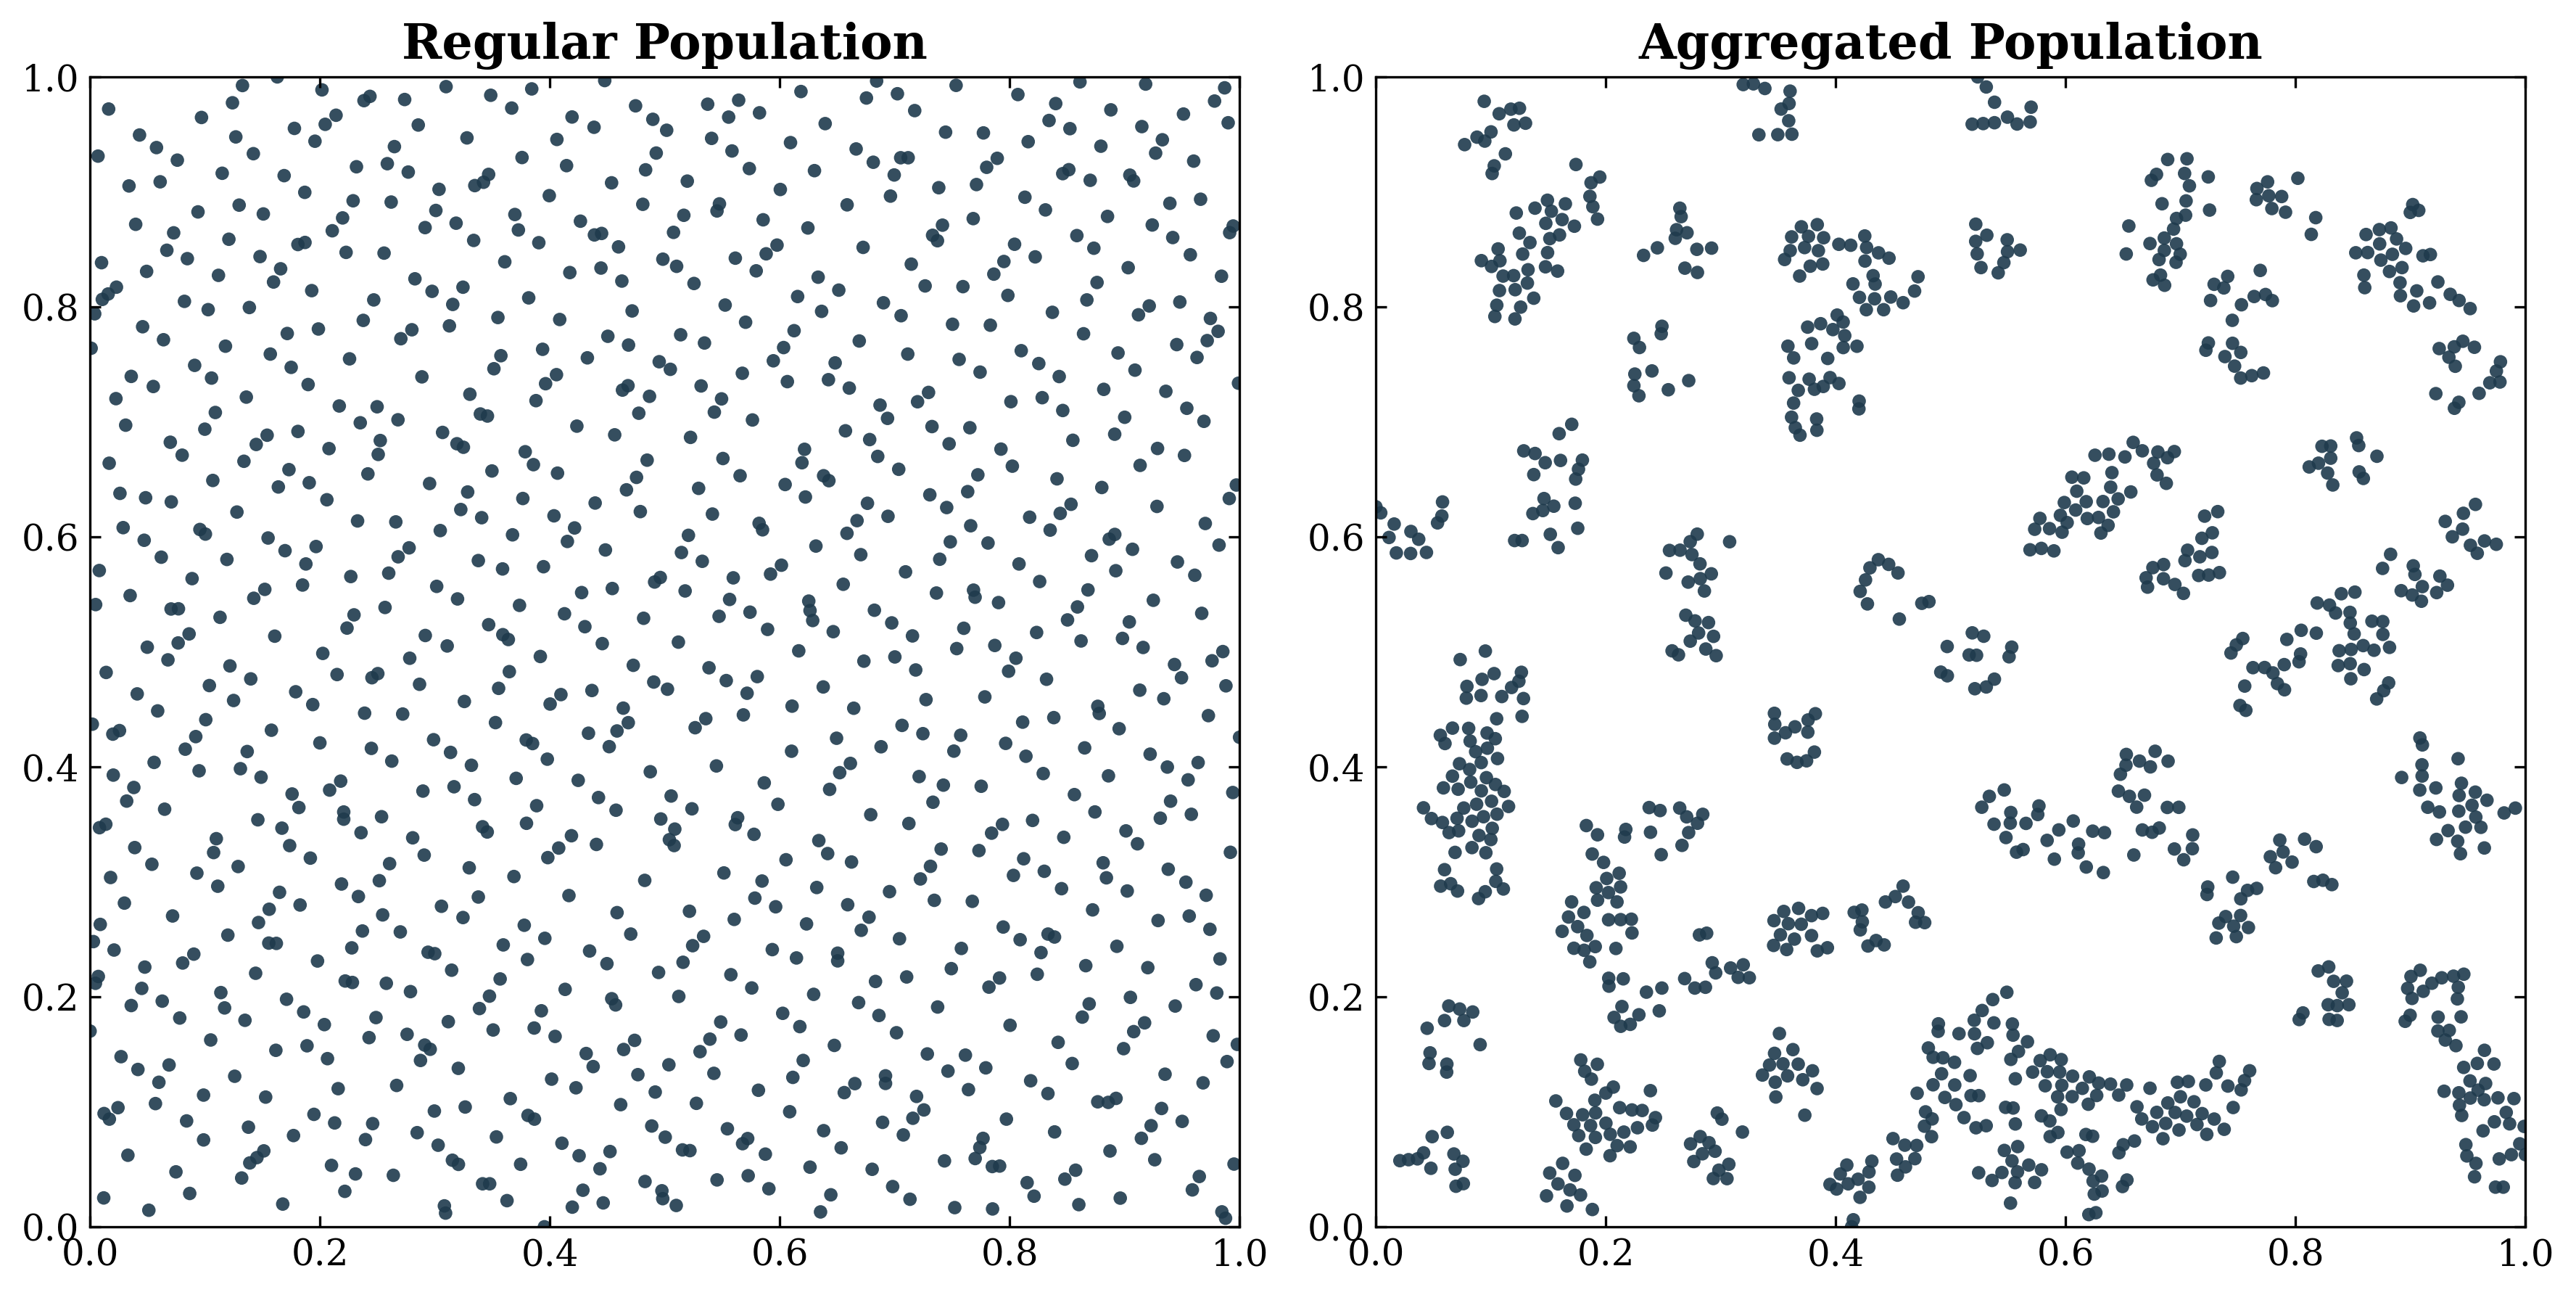

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data generated by the OpenCV script
try:
    df_regular = pd.read_csv('precise_regular_population.csv')
    df_aggregated = pd.read_csv('precise_aggregated_population.csv')
except FileNotFoundError:
    print("Error: Could not find the CSV files. Make sure the extraction script ran successfully.")
    exit()

# 2. Set up professional, academic-quality plot formatting
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif', # Standard for academic papers
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (12, 6), # Wide layout for side-by-side
    'figure.dpi': 300 # High resolution for publications/slides
})

# Create a 1x2 subplot structure
fig, axes = plt.subplots(1, 2)

# ---------------------------------------------------------
# Plot 1: Regular Population
# ---------------------------------------------------------
axes[0].scatter(df_regular['x'], df_regular['y'], 
                c='#1f3b4d', # A deep, professional blue-black
                s=20,        # Dot size
                alpha=0.9, 
                edgecolors='none')
axes[0].set_title('Regular Population', fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect('equal') # Forces the unit box to be a perfect square
axes[0].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[0].tick_params(direction='in', top=True, right=True) # Ticks point inward like the paper

# ---------------------------------------------------------
# Plot 2: Aggregated Population
# ---------------------------------------------------------
axes[1].scatter(df_aggregated['x'], df_aggregated['y'], 
                c='#1f3b4d', 
                s=20, 
                alpha=0.9, 
                edgecolors='none')
axes[1].set_title('Aggregated Population', fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect('equal')
axes[1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1].tick_params(direction='in', top=True, right=True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure as a high-quality PNG
plt.savefig('reconstructed_populations.png', bbox_inches='tight')

# Display the plot in the Jupyter/IPython window
plt.show()

In [ ]:
os.getcwd()


NameError: name 'os' is not defined

In [ ]:
C:\Users\Apc\graphical-sampling\simulations\plot\aggregated_plot.png